In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.metrics import (roc_auc_score, classification_report, 
                              confusion_matrix, roc_curve)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load processed data
X_train = pd.read_csv('../data/processed/X_train.csv')
X_val = pd.read_csv('../data/processed/X_val.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_val = pd.read_csv('../data/processed/y_val.csv').squeeze()
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

print(f"Training set: {X_train.shape}")
print(f"Validation set: {X_val.shape}")
print(f"Test set: {X_test.shape}")
print(f"\nFeatures: {X_train.columns.tolist()}")

Training set: (104999, 12)
Validation set: (22500, 12)
Test set: (22500, 12)

Features: ['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents', 'total_late_payments', 'debt_to_income']


In [2]:
# ============================================================
# TRAIN LIGHTGBM MODEL
# ============================================================

# Calculate class weight for imbalanced data
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

# LightGBM parameters
params = {
    'objective': 'binary',
    'metric': 'auc',
    'scale_pos_weight': scale_pos_weight,
    'learning_rate': 0.05,
    'num_leaves': 31,
    'max_depth': -1,
    'min_child_samples': 20,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'reg_alpha': 0.1,
    'reg_lambda': 0.1,
    'random_state': 42,
    'verbose': -1
}

# Create LightGBM datasets
train_data = lgb.Dataset(X_train, label=y_train)
val_data = lgb.Dataset(X_val, label=y_val, reference=train_data)

# Train model with early stopping
callbacks = [
    lgb.early_stopping(stopping_rounds=50, verbose=True),
    lgb.log_evaluation(period=100)
]

model = lgb.train(
    params,
    train_data,
    num_boost_round=1000,
    valid_sets=[train_data, val_data],
    valid_names=['train', 'val'],
    callbacks=callbacks
)

print(f"\nBest iteration: {model.best_iteration}")
print(f"Best validation AUC: {model.best_score['val']['auc']:.4f}")

scale_pos_weight: 13.96
Training until validation scores don't improve for 50 rounds
[100]	train's auc: 0.889012	val's auc: 0.869223
[200]	train's auc: 0.902176	val's auc: 0.869016
Early stopping, best iteration is:
[151]	train's auc: 0.896099	val's auc: 0.869699

Best iteration: 151
Best validation AUC: 0.8697


Test AUC-ROC: 0.8641

Classification Report:
              precision    recall  f1-score   support

  No Default       0.98      0.81      0.88     20996
     Default       0.22      0.76      0.34      1504

    accuracy                           0.80     22500
   macro avg       0.60      0.78      0.61     22500
weighted avg       0.93      0.80      0.85     22500



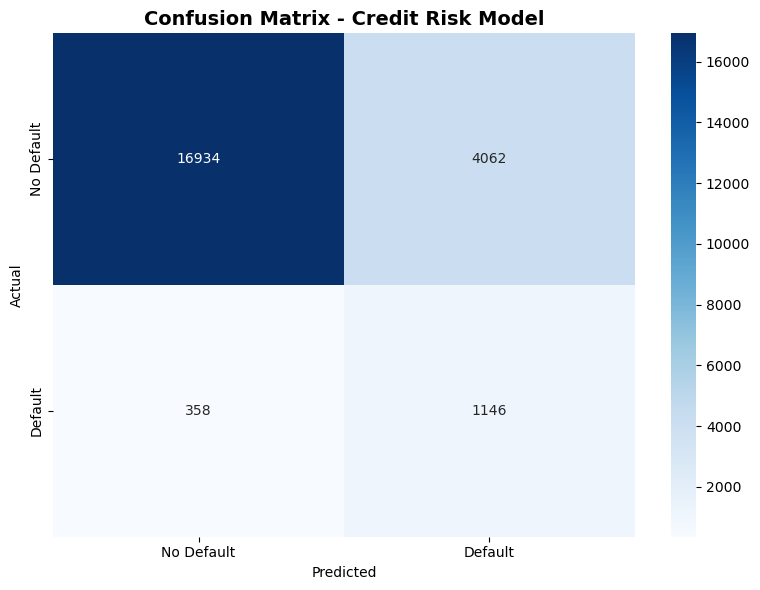

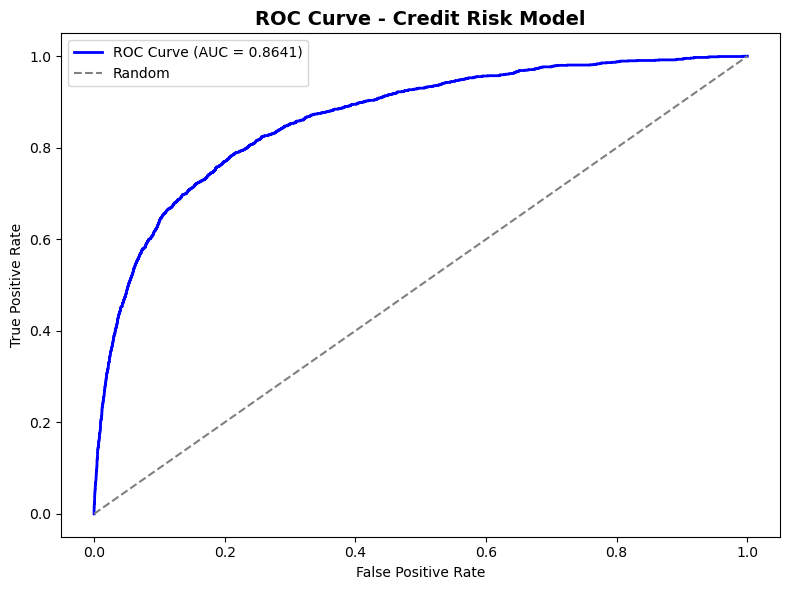

Evaluation plots saved


In [3]:
# ============================================================
# EVALUATE ON TEST SET
# ============================================================

# Predictions
y_pred_proba = model.predict(X_test, num_iteration=model.best_iteration)
y_pred = (y_pred_proba >= 0.5).astype(int)

# AUC-ROC
auc = roc_auc_score(y_test, y_pred_proba)
print(f"Test AUC-ROC: {auc:.4f}")

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Default', 'Default']))

# Confusion matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Default', 'Default'],
            yticklabels=['No Default', 'Default'])
plt.title('Confusion Matrix - Credit Risk Model', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('../reports/confusion_matrix.png', dpi=100, bbox_inches='tight')
plt.show()

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Credit Risk Model', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/roc_curve.png', dpi=100, bbox_inches='tight')
plt.show()
print("Evaluation plots saved")

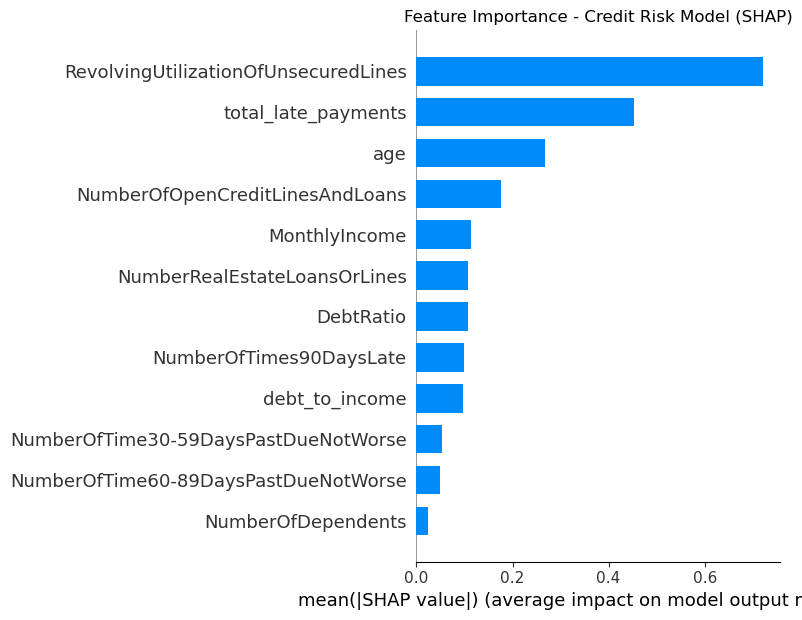

SHAP importance plot saved


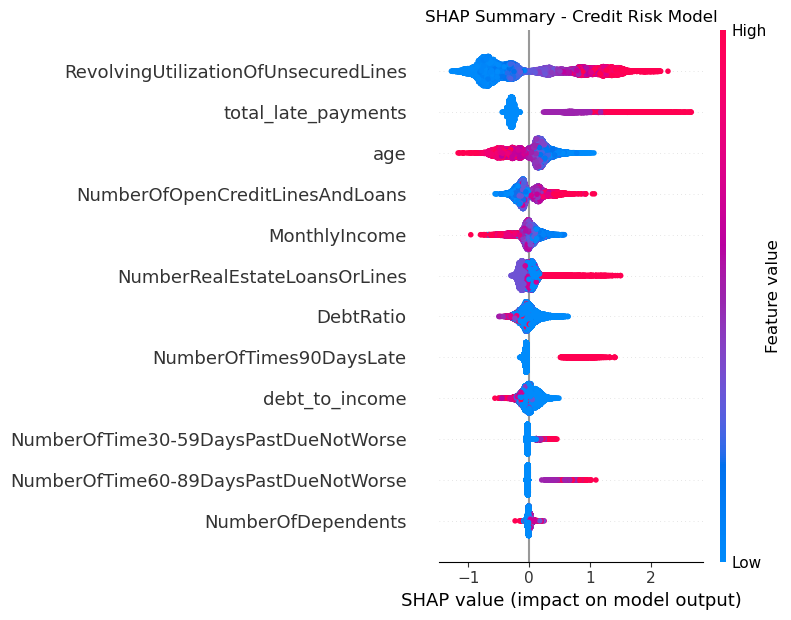

SHAP summary plot saved


In [4]:
import shap

# ============================================================
# SHAP EXPLAINABILITY
# ============================================================

# Create SHAP explainer
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Plot 1 - Feature importance
plt.figure()
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("Feature Importance - Credit Risk Model (SHAP)")
plt.tight_layout()
plt.savefig('../reports/shap_importance.png', dpi=100, bbox_inches='tight')
plt.show()
print("SHAP importance plot saved")

# Plot 2 - SHAP summary dot plot
plt.figure()
shap.summary_plot(shap_values, X_test, show=False)
plt.title("SHAP Summary - Credit Risk Model")
plt.tight_layout()
plt.savefig('../reports/shap_summary.png', dpi=100, bbox_inches='tight')
plt.show()
print("SHAP summary plot saved")

In [5]:
import joblib
import os

# ============================================================
# SAVE MODEL AND ARTIFACTS
# ============================================================

os.makedirs('../models', exist_ok=True)

# Save model
joblib.dump(model, '../models/credit_risk_lgbm.pkl')

# Save feature columns
feature_cols = X_train.columns.tolist()
joblib.dump(feature_cols, '../models/feature_cols.pkl')

# Save SHAP explainer
joblib.dump(explainer, '../models/shap_explainer.pkl')

# Save model metadata
import json
metadata = {
    'model_type': 'LightGBM',
    'auc_roc_test': round(auc, 4),
    'best_iteration': model.best_iteration,
    'n_features': len(feature_cols),
    'features': feature_cols,
    'scale_pos_weight': round(scale_pos_weight, 2),
    'training_samples': len(X_train),
    'test_samples': len(X_test),
    'default_rate_train': round(float(y_train.mean()), 4)
}

with open('../models/model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("Model saved successfully")
print(f"Files saved:")
print(f"  - models/credit_risk_lgbm.pkl")
print(f"  - models/feature_cols.pkl")
print(f"  - models/shap_explainer.pkl")
print(f"  - models/model_metadata.json")

Model saved successfully
Files saved:
  - models/credit_risk_lgbm.pkl
  - models/feature_cols.pkl
  - models/shap_explainer.pkl
  - models/model_metadata.json
